# AIG4B — Clase 12
## Práctica: ECG, EEG y PPG — lo esencial

Tarea acompañante de la **Clase 12** (señales 1D biomédicas). Los datos vienen hechos; los **modelos los implementan ustedes** siguiendo las especificaciones del PDF de la clase.

Ejercicios:

- **1.1** — usar `neurokit2` para estimar bpm en ECG sintético.
- **1.2** — implementar la **toy CNN** de slide 21 y entrenarla para clasificar arritmias.
- **2.1** — implementar **EEGNet** siguiendo slide 29 para clasificar carga cognitiva.
- **3.1** — implementar un **mini-Transformer 1D** y verificar que resuelve la tarea de contexto largo donde una CNN falla.

Autores: Paulo Veiga y Marco Sanchez Sorondo · Mayo 2026

## Setup

La primera celda instala lo que falte (necesario en Colab).

In [ ]:
import importlib, subprocess, sys
for pkg in ['wfdb', 'neurokit2']:
    try: importlib.import_module(pkg)
    except ImportError:
        print(f'instalando {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('listo')

instalando wfdb...
instalando neurokit2...
listo


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sps
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import wfdb, neurokit2 as nk

np.random.seed(0); torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
plt.rcParams['figure.figsize'] = (11, 3.5)
plt.rcParams['axes.grid'] = True
print(f'torch v{torch.__version__}  device={device}')

torch v2.11.0+cpu  device=cpu


## 1. ECG

**Idea central (slides 11, 14, 21):** un ECG es una secuencia de números + `fs`. La detección clásica de R-peaks es Pan-Tompkins; la versión AI usa CNNs. Para arritmias, una CNN simple ya supera lo que se podría hacer a mano con reglas R-R.

Cargamos un registro real de **MIT-BIH** (PhysioNet) y vemos cómo `neurokit2` lo procesa.

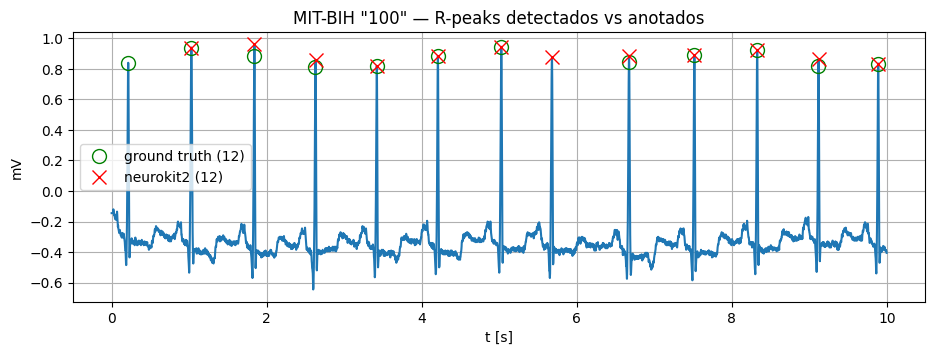

In [ ]:
FS_ECG = 360
record = wfdb.rdrecord('100', pn_dir='mitdb', sampto=10*FS_ECG)
ecg_raw = record.p_signal[:, 0]
t_ecg = np.arange(len(ecg_raw)) / FS_ECG

ann = wfdb.rdann('100', 'atr', pn_dir='mitdb', sampto=10*FS_ECG)
r_gt = np.array([s for s, sym in zip(ann.sample, ann.symbol) if sym == 'N'])

_, info = nk.ecg_peaks(ecg_raw, sampling_rate=FS_ECG)
r_nk = info['ECG_R_Peaks']

plt.plot(t_ecg, ecg_raw)
plt.plot(t_ecg[r_gt], ecg_raw[r_gt], 'go', ms=10, mfc='none', label=f'ground truth ({len(r_gt)})')
plt.plot(t_ecg[r_nk], ecg_raw[r_nk], 'rx', ms=10, label=f'neurokit2 ({len(r_nk)})')
plt.xlabel('t [s]'); plt.ylabel('mV'); plt.legend()
plt.title('MIT-BIH "100" — R-peaks detectados vs anotados')
plt.show()

### Helper · generador de ECG sintético

Función provista para los ejercicios. **No es parte del ejercicio**, solo úsenla.

In [ ]:
def synthetic_ecg(duration_s, fs, hr_bpm):
    """ECG sintético: suma de gaussianas P-Q-R-S-T repetidas a hr_bpm."""
    t = np.arange(0, duration_s, 1/fs); rr = 60.0/hr_bpm
    ecg = np.zeros_like(t)
    waves = [(0.00,0.025,0.15),(0.15,0.010,-0.10),(0.17,0.008,1.20),(0.19,0.010,-0.25),(0.35,0.04,0.35)]
    for k in range(int(duration_s/rr)+1):
        t0 = k * rr
        for off, sigma, amp in waves:
            ecg += amp * np.exp(-((t-t0-off)**2)/(2*sigma**2))
    return t, ecg

### Ejercicio 1.1 — estimar bpm con `neurokit2`

1. Generá un ECG sintético de 30 s con frecuencia cardíaca aleatoria entre 50 y 110 bpm (sin imprimir cuál).
2. Usá `nk.ecg_peaks` para detectar los R-peaks.
3. Estimá la frecuencia cardíaca a partir de los intervalos R-R y comparala con el valor real.

HR real:     96.4 bpm
HR estimada: 96.4 bpm
Error:       0.00 bpm (0.0%)


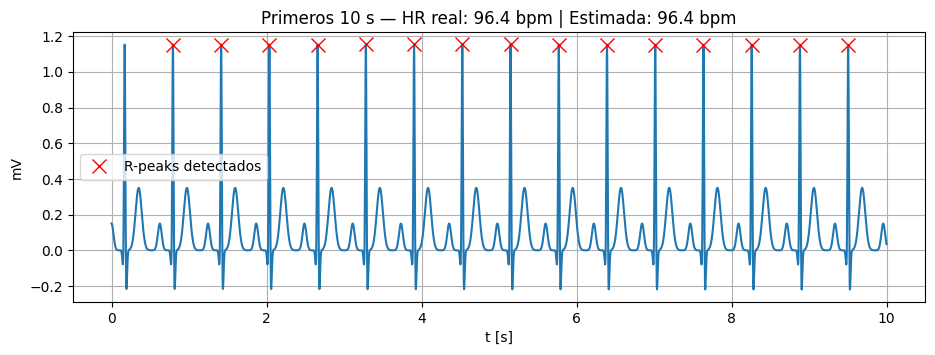

In [ ]:
# 1. Generar ECG sintético con HR aleatoria
rng_1 = np.random.default_rng(42)
hr_real = float(rng_1.uniform(50, 110))  # no imprimirlo antes
t_syn, ecg_syn = synthetic_ecg(30.0, FS_ECG, hr_bpm=hr_real)

# 2. Detectar R-peaks con neurokit2
_, info_syn = nk.ecg_peaks(ecg_syn, sampling_rate=FS_ECG)
r_peaks_syn = info_syn['ECG_R_Peaks']

# 3. Estimar HR a partir de intervalos R-R
rr_s = np.diff(r_peaks_syn) / FS_ECG       # intervalos R-R en segundos
hr_est = 60.0 / np.mean(rr_s)

print(f'HR real:     {hr_real:.1f} bpm')
print(f'HR estimada: {hr_est:.1f} bpm')
print(f'Error:       {abs(hr_est - hr_real):.2f} bpm ({abs(hr_est - hr_real)/hr_real*100:.1f}%)')

plt.plot(t_syn[:int(10*FS_ECG)], ecg_syn[:int(10*FS_ECG)])
plt.plot(t_syn[r_peaks_syn[r_peaks_syn < int(10*FS_ECG)]],
         ecg_syn[r_peaks_syn[r_peaks_syn < int(10*FS_ECG)]],
         'rx', ms=10, label=f'R-peaks detectados')
plt.xlabel('t [s]'); plt.ylabel('mV')
plt.title(f'Primeros 10 s — HR real: {hr_real:.1f} bpm | Estimada: {hr_est:.1f} bpm')
plt.legend(); plt.show()


### Dataset de arritmias (provisto)

Tres clases (slide 13): **normal** (RR regular), **AFIB** (RR aleatorio + morfología sucia), **bigeminismo** (RR alternante corto-largo). El dataset y el split train/val vienen hechos; ustedes se ocupan del modelo.

Train: (720, 500)  Val: (180, 500)  Clases: ['normal', 'AFIB', 'bigeminismo']


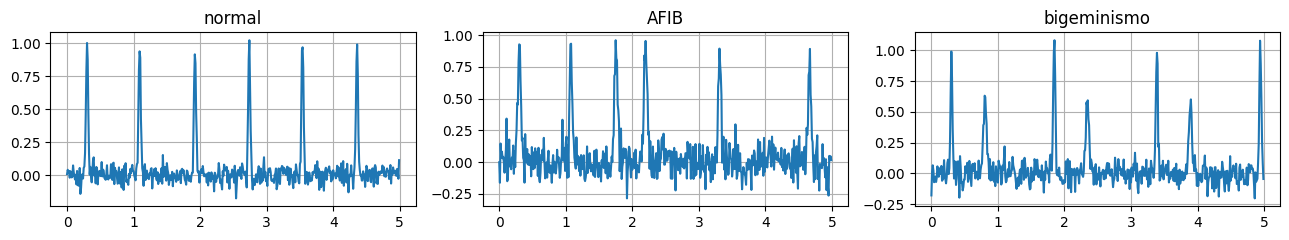

In [ ]:
FS = 100; WIN = 500  # 5 s a 100 Hz

def make_rr_window(label, rng):
    t = np.arange(WIN) / FS
    sig = np.zeros(WIN, dtype=np.float32)
    if label == 0:
        hr = rng.uniform(60, 80)
        rrs = np.full(15, 60/hr) + rng.normal(0, 0.02, 15)
        amps, widths, noise = np.full(15, 1.0), np.full(15, 0.015), 0.05
    elif label == 1:
        rrs = rng.uniform(0.4, 1.4, 15)
        amps = np.full(15, 0.9) + rng.normal(0, 0.10, 15)
        widths = rng.uniform(0.018, 0.025, 15); noise = 0.10
    else:
        s = rng.uniform(0.45, 0.55); l = rng.uniform(1.05, 1.20)
        rrs = np.array([s, l] * 8)[:15] + rng.normal(0, 0.02, 15)
        amps = np.array([1.0, 0.6] * 8)[:15]
        widths = np.array([0.015, 0.025] * 8)[:15]; noise = 0.07
    t_pos = 0.3
    for rr, amp, w in zip(rrs, amps, widths):
        if t_pos >= WIN / FS: break
        sig += amp * np.exp(-((t - t_pos) ** 2) / (2 * w ** 2))
        t_pos += rr
    return sig + noise * rng.standard_normal(WIN).astype(np.float32)

rng = np.random.default_rng(0); n_per = 300
labels_arr = ['normal', 'AFIB', 'bigeminismo']
X = np.stack([make_rr_window(c, rng) for c in [0]*n_per + [1]*n_per + [2]*n_per])
y = np.array([0]*n_per + [1]*n_per + [2]*n_per, dtype=np.int64)
idx = rng.permutation(len(X)); X, y = X[idx], y[idx]
split = int(0.8*len(X))
X_tr, X_va, y_tr, y_va = X[:split], X[split:], y[:split], y[split:]
print(f'Train: {X_tr.shape}  Val: {X_va.shape}  Clases: {labels_arr}')

fig, axes = plt.subplots(1, 3, figsize=(13, 2.5))
for ax, c in zip(axes, [0, 1, 2]):
    ax.plot(np.arange(WIN)/FS, X[y == c][0])
    ax.set_title(labels_arr[c])
plt.tight_layout(); plt.show()

### Ejercicio 1.2 — implementar y entrenar la toy CNN (slide 21)

Implementá **exactamente** la arquitectura de la slide 21 y entrenala sobre el dataset de arritmias.

**Arquitectura:**
```
Conv1D(in=1, out=16, kernel_size=5)  →  ReLU  →  MaxPool1D(kernel=2)
Conv1D(in=16, out=32, kernel_size=5) →  ReLU
GlobalAvgPool1D  →  Flatten  →  Linear(32, 3)
```

**Entrenamiento:** 15 epochs, optimizer Adam (lr=1e-3), loss `CrossEntropyLoss`, batch size 32.

**Reportar:**
- `val_acc` final
- matriz de confusión 3×3
- **sensibilidad** (recall) y **especificidad** por clase (las dos métricas clínicas clave)

*Pista para GlobalAvgPool1D:* en PyTorch se logra con `nn.AdaptiveAvgPool1d(1)` seguido de `nn.Flatten()`.

Parámetros: 2,787
Epoch  5/15 | loss=1.0791 | val_acc=0.6500
Epoch 10/15 | loss=0.9560 | val_acc=0.6500
Epoch 15/15 | loss=0.6759 | val_acc=0.9722

==> val_acc final: 0.9722


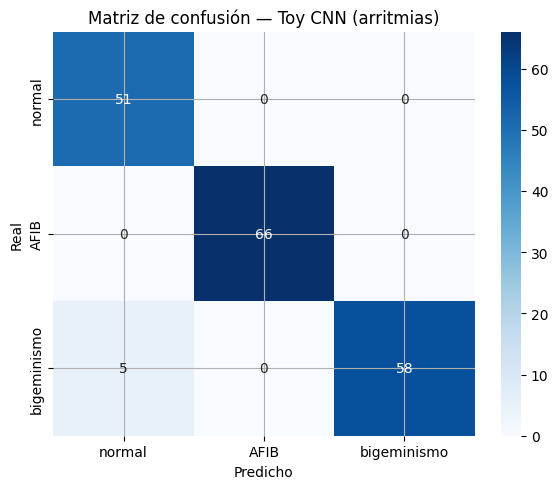


Classification report:
              precision    recall  f1-score   support

      normal       0.91      1.00      0.95        51
        AFIB       1.00      1.00      1.00        66
 bigeminismo       1.00      0.92      0.96        63

    accuracy                           0.97       180
   macro avg       0.97      0.97      0.97       180
weighted avg       0.97      0.97      0.97       180

normal       | Sensibilidad: 1.000 | Especificidad: 0.961
AFIB         | Sensibilidad: 1.000 | Especificidad: 1.000
bigeminismo  | Sensibilidad: 0.921 | Especificidad: 1.000


In [ ]:
class ToyCNN(nn.Module):
    """CNN exactamente como slide 21.
    Input: [B, 1, 500] (1 canal, 500 muestras = 5 s a 100 Hz)

    Conv1D(1, 16, 5) → ReLU → MaxPool1d(2)   [500 → 248]
    Conv1D(16, 32, 5) → ReLU                  [248 → 244]
    AdaptiveAvgPool1d(1) → Flatten             [244 → 1 → 32]
    Linear(32, 3)
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5),   # 500 → 496
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),        # 496 → 248
            nn.Conv1d(16, 32, kernel_size=5),   # 248 → 244
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),            # 244 → 1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                        # [B, 32, 1] → [B, 32]
            nn.Linear(32, 3),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# Entrenamiento
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def train_ecg_clf(model, X_tr, y_tr, X_va, y_va, epochs=15, lr=1e-3, bs=32):
    """Entrena un clasificador de señales 1D y retorna el historial."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    ds = TensorDataset(torch.from_numpy(X_tr).float().unsqueeze(1), torch.from_numpy(y_tr))
    loader = DataLoader(ds, batch_size=bs, shuffle=True)
    history = {'train_loss': [], 'val_acc': []}
    for ep in range(epochs):
        model.train(); total_loss = 0; n = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = crit(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
            total_loss += loss.item() * xb.size(0); n += xb.size(0)
        model.eval()
        with torch.no_grad():
            xv = torch.from_numpy(X_va).float().unsqueeze(1).to(device)
            preds = model(xv).argmax(1).cpu().numpy()
        val_acc = (preds == y_va).mean()
        history['train_loss'].append(total_loss / n)
        history['val_acc'].append(val_acc)
        if (ep + 1) % 5 == 0:
            print(f'Epoch {ep+1:2d}/{epochs} | loss={total_loss/n:.4f} | val_acc={val_acc:.4f}')
    return history, preds

torch.manual_seed(0)
toy_cnn = ToyCNN().to(device)
print(f'Parámetros: {sum(p.numel() for p in toy_cnn.parameters()):,}')
hist_toy, preds_toy = train_ecg_clf(toy_cnn, X_tr, y_tr, X_va, y_va, epochs=15)
print(f'\n==> val_acc final: {hist_toy["val_acc"][-1]:.4f}')

# Matriz de confusión
cm_toy = confusion_matrix(y_va, preds_toy)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_toy, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_arr, yticklabels=labels_arr)
plt.xlabel('Predicho'); plt.ylabel('Real')
plt.title('Matriz de confusión — Toy CNN (arritmias)')
plt.tight_layout(); plt.show()

print('\nClassification report:')
print(classification_report(y_va, preds_toy, target_names=labels_arr))

# Sensibilidad y especificidad por clase
for i, cls in enumerate(labels_arr):
    tp = cm_toy[i, i]
    fn = cm_toy[i, :].sum() - tp
    fp = cm_toy[:, i].sum() - tp
    tn = cm_toy.sum() - tp - fn - fp
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f'{cls:12s} | Sensibilidad: {sens:.3f} | Especificidad: {spec:.3f}')


### Preguntas conceptuales — toy CNN (Ej 1.2)

Justificá brevemente cada decisión de la arquitectura y del entrenamiento. Una o dos oraciones por pregunta.

1. ¿Por qué usamos `Conv1D` en vez de `Linear` para procesar la señal?
2. `kernel_size=5` a `fs=100 Hz`: ¿cuántos milisegundos cubre el kernel? ¿Por qué ese tamaño tiene sentido para un ECG?
3. ¿Para qué sirve `MaxPool1d(2)`?
4. ¿Por qué la segunda Conv1D pasa de 16 a 32 filtros (el número crece al profundizar)?
5. ¿Qué hace `AdaptiveAvgPool1d(1)`? ¿Qué se gana y qué se pierde al colapsar toda la dimensión temporal?
6. ¿Por qué la última capa `Linear` tiene **3** outputs y no hay activación softmax después?
7. ¿Por qué `CrossEntropyLoss` es la loss apropiada y por qué usamos `Adam` y no `SGD`?



1.   Conv1D porque la señal tiene estructura temporal local: el mismo patrón (QRS) puede aparecer en cualquier posición. Linear trataría cada posición como un feature independiente — no puede capturar patrones que se deslizan.
2.   kernel=5 a 100 Hz = 5/100 = 50 ms. Tiene sentido: el QRS dura 60-100 ms, así que un kernel de 50ms captura un flanco del QRS. Kernels más chicos verían sub-componentes; más grandes mezclarían varias ondas.
3.   MaxPool1d(2) reduce la resolución temporal a la mitad y hace la representación invariante a pequeñas traslaciones del patrón. También reduce el costo computacional para la segunda capa.
4.   La segunda capa tiene más filtros porque aprende combinaciones de los features de la primera. Las capas profundas capturan patrones más complejos que requieren más "vocabulario" de representaciones.
5.   AdaptiveAvgPool1d(1) promedia todos los timesteps restantes en un único valor por canal. Se gana invarianza completa a la posición y la red acepta señales de cualquier largo. Se pierde información sobre dónde en la señal ocurrió el patrón (bueno para clasificación global, malo si necesitás localización).
6.   3 outputs porque hay 3 clases (normal, AFIB, bigeminismo). No hay softmax explícito porque CrossEntropyLoss lo incluye internamente al calcular log-softmax + NLLLoss.
7.   CrossEntropyLoss es apropiada para clasificación multiclase con etiquetas enteras. Adam es preferido sobre SGD en datasets medianos y redes moderadas porque adapta la tasa de aprendizaje por parámetro, converge más rápido y requiere menos tuning del lr.






## 2. EEG

**Idea central (slides 25, 27, 29):** EEG es una **matriz** `[canales × tiempo]`, no un vector. **EEGNet** (Lawhern 2018) es el baseline estándar. Lo implementamos siguiendo la slide 29 del PDF.

Dataset sintético con bandas EEG realistas: carga cognitiva **baja** (predominio α) vs **alta** (predominio β).

In [ ]:
FS_EEG = 128; N_CHANS = 14; N_SAMPLES = 128  # 1 segundo
BANDS = {'delta':(0.5,4), 'theta':(4,8), 'alpha':(8,12), 'beta':(13,30)}

def make_eeg_epoch(label, rng):
    if label == 0:
        amps = {'delta':0.5, 'theta':0.5, 'alpha':1.5, 'beta':0.3}
    else:
        amps = {'delta':0.5, 'theta':0.5, 'alpha':0.3, 'beta':1.5}
    t = np.arange(N_SAMPLES) / FS_EEG
    eeg = np.zeros((N_CHANS, N_SAMPLES), dtype=np.float32)
    for c in range(N_CHANS):
        for band, amp in amps.items():
            lo, hi = BANDS[band]
            eeg[c] += amp * np.sin(2*np.pi*rng.uniform(lo, hi)*t + rng.uniform(0, 2*np.pi))
        eeg[c] += 0.2 * rng.standard_normal(N_SAMPLES)
    return eeg

rng = np.random.default_rng(5); n_per = 300
X_eeg = np.stack([make_eeg_epoch(c, rng) for c in [0]*n_per + [1]*n_per])
y_eeg = np.array([0]*n_per + [1]*n_per, dtype=np.int64)
idx = rng.permutation(len(X_eeg)); X_eeg, y_eeg = X_eeg[idx], y_eeg[idx]
split = int(0.8*len(X_eeg))
X_tr_e, X_va_e = X_eeg[:split], X_eeg[split:]
y_tr_e, y_va_e = y_eeg[:split], y_eeg[split:]
print('Train:', X_tr_e.shape, 'Val:', X_va_e.shape)

Train: (480, 14, 128) Val: (120, 14, 128)


### Ejercicio 2.1 — implementar y entrenar EEGNet (slide 29)

Implementá EEGNet siguiendo la slide 29 del PDF y entrenala para clasificar carga cognitiva (baja vs alta).

**Arquitectura (slide 29):**

```
Input [batch, 1, C=14, T=128]

BLOQUE 1 — temporal conv
  Conv2D(in=1, out=F1=8, kernel=(1, 64), padding=(0, 32), bias=False)
  BatchNorm2d(F1)

BLOQUE 2 — depthwise spatial conv (combina canales)
  Conv2D(in=F1, out=F1*D=16, kernel=(C=14, 1), groups=F1, bias=False)
  BatchNorm2d(F1*D)  →  ELU  →  AvgPool2D(kernel=(1, 4))  →  Dropout(0.25)

BLOQUE 3 — separable conv
  Conv2D depthwise: kernel=(1, 16), groups=F1*D, padding=(0, 8), bias=False
  Conv2D pointwise: kernel=(1, 1), out=F2=16, bias=False
  BatchNorm2d(F2)  →  ELU  →  AvgPool2D(kernel=(1, 8))  →  Dropout(0.25)

HEAD
  Flatten  →  Linear(→ 2 clases)
```

**Entrenamiento:** 10 epochs, Adam (lr=1e-3), `CrossEntropyLoss`, batch size 32.

**Tip:** el tensor entra como `[B, C, T]`. Tenés que agregarle la dimensión de canal con `x.unsqueeze(1)` antes del primer Conv2D para que quede `[B, 1, C, T]`.

In [ ]:
class EEGNet(nn.Module):
    """EEGNet para clasificación EEG de 2 clases.
    Input: [B, C=14, T=128] — se unsqueezeará a [B, 1, 14, 128]
    F1=8, D=2, F2=16
    """
    def __init__(self, n_chans=14, n_samples=128, n_classes=2, F1=8, D=2, F2=16, dropout=0.25):
        super().__init__()
        T_after_pool2 = n_samples // 4    # después de AvgPool(1,4) → 32
        T_after_pool3 = T_after_pool2 // 8  # después de AvgPool(1,8) → 4

        # Bloque 1 — temporal conv
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1),
        )

        # Bloque 2 — depthwise spatial conv
        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F1 * D, kernel_size=(n_chans, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout),
        )

        # Bloque 3 — separable conv
        self.block3 = nn.Sequential(
            # depthwise
            nn.Conv2d(F1 * D, F1 * D, kernel_size=(1, 16), groups=F1 * D,
                      padding=(0, 8), bias=False),
            # pointwise
            nn.Conv2d(F1 * D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout),
        )

        # Head
        flat_size = F2 * 1 * T_after_pool3
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, n_classes),
        )

    def forward(self, x):
        # x: [B, C, T] → [B, 1, C, T]
        x = x.unsqueeze(1)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

torch.manual_seed(0)
eegnet = EEGNet(n_chans=N_CHANS, n_samples=N_SAMPLES, n_classes=2).to(device)
print(f'Parámetros: {sum(p.numel() for p in eegnet.parameters()):,}')

def train_eeg_clf(model, X_tr, y_tr, X_va, y_va, epochs=10, lr=1e-3, bs=32):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    ds = TensorDataset(torch.from_numpy(X_tr).float(), torch.from_numpy(y_tr))
    loader = DataLoader(ds, batch_size=bs, shuffle=True)
    for ep in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = crit(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            xv = torch.from_numpy(X_va).float().to(device)
            val_acc = (model(xv).argmax(1).cpu().numpy() == y_va).mean()
        if (ep + 1) % 2 == 0 or ep == epochs - 1:
            print(f'Epoch {ep+1:2d}/{epochs} | val_acc={val_acc:.4f}')
    return val_acc

val_acc_eeg = train_eeg_clf(eegnet, X_tr_e, y_tr_e, X_va_e, y_va_e, epochs=10)
print(f'\n==> EEGNet val_acc: {val_acc_eeg:.4f}')


Parámetros: 1,458
Epoch  2/10 | val_acc=0.9917
Epoch  4/10 | val_acc=1.0000
Epoch  6/10 | val_acc=1.0000
Epoch  8/10 | val_acc=1.0000
Epoch 10/10 | val_acc=1.0000

==> EEGNet val_acc: 1.0000


### Preguntas conceptuales — EEGNet (Ej 2.1)

Justificá brevemente cada decisión de la arquitectura. Una o dos oraciones por pregunta.

1. La primera conv tiene kernel `(1, 64)`. ¿Por qué solo en el eje temporal (alto 1) y no en el espacial?
2. A `fs=128 Hz`, ¿cuántos segundos cubre un kernel de 64? ¿Por qué tiene sentido ese tamaño para EEG?
3. La segunda conv tiene kernel `(C=14, 1)` (todo el eje de canales) y `groups=F1` (depthwise). ¿Qué aprende esa conv? ¿Por qué es depthwise?
4. ¿Qué representa el **depth multiplier** `D=2`?
5. ¿Por qué `AvgPool2d` en vez de `MaxPool2d`? ¿Y por qué `ELU` en vez de `ReLU`?
6. ¿Qué es una **separable convolution** (depthwise + pointwise)? ¿Por qué se usa en vez de una conv estándar?
7. El pool del bloque 3 es `(1, 8)`, más grande que el del bloque 2 `(1, 4)`. ¿Por qué se vuelve más agresivo al final?
8. ¿Para qué sirve `Dropout(0.25)`?

1. La primera conv filtra solo en el eje temporal (alto=1) porque el EEG es multicanal — no tiene sentido mezclar canales aquí. Los canales representan electrodos en posiciones espaciales distintas; se procesan primero en el tiempo y luego espacialmente (Bloque 2).
2. kernel=64 a 128 Hz = 64/128 = 0.5 s. Tiene sentido para EEG: captura ciclos completos de las bandas de baja frecuencia (delta: 0.5-4 Hz tiene período ≥ 250 ms; alpha: período de 83-125 ms). Un kernel de 0.5 s integra suficiente señal para caracterizar el ritmo dominante.
3. La segunda conv tiene kernel (C, 1) — colapsa todos los electrodos — y es depthwise (groups=F1). Aprende cómo combinar espacialmente los electrodos para cada filtro temporal. Es depthwise para mantener separados los filtros del bloque 1 — no queremos que mezclen información entre filtros temporales distintos.
4. D=2 es el depth multiplier: por cada filtro temporal del Bloque 1, se aprenden D=2 combinaciones espaciales distintas. Da más expresividad sin aumentar mucho los parámetros.
5. AvgPool porque en EEG nos interesa la potencia espectral en una banda (promedio sobre tiempo), no el valor pico. ELU en vez de ReLU porque ELU tiene gradiente suave para valores negativos (no muere a cero), lo que ayuda en señales EEG que son bipolares y pequeñas.
6. Separable = depthwise (filtro por canal) + pointwise (mezcla de canales). Reduce parámetros: conv estándar k² × Cin × Cout vs separable k² × Cin (DW) + Cin × Cout (PW). Esto previene overfitting con datasets EEG pequeños.
7. El pooling del Bloque 3 es (1,8) vs (1,4) del Bloque 2 para comprimir más agresivamente la dimensión temporal después de que ya capturamos las features relevantes. Al final del bloque 3, la resolución temporal es baja → tiene sentido colapsar más.
8. Dropout(0.25) regulariza: durante entrenamiento desactiva 25% de las neuronas aleatoriamente, forzando que la red no dependa de ningún feature específico y generalizando mejor.

## 3. CNN ↔ Transformer — campo receptivo y atención (slides 31–33)

**Lo que el PDF quiere mostrar:** una CNN tiene **campo receptivo finito** (slide 31). Un Transformer mira **toda la secuencia** de una sola pasada (slide 32) usando **self-attention** (slide 33).

Tarea: ventanas de 30 s con dos *spike trains* — uno al segundo 1, otro al segundo 25 — cada uno a 5 Hz o 12 Hz. Preguntamos si matchean. Para responder hay que comparar dos eventos separados **24 segundos** — fuera del campo receptivo de una CNN razonable.

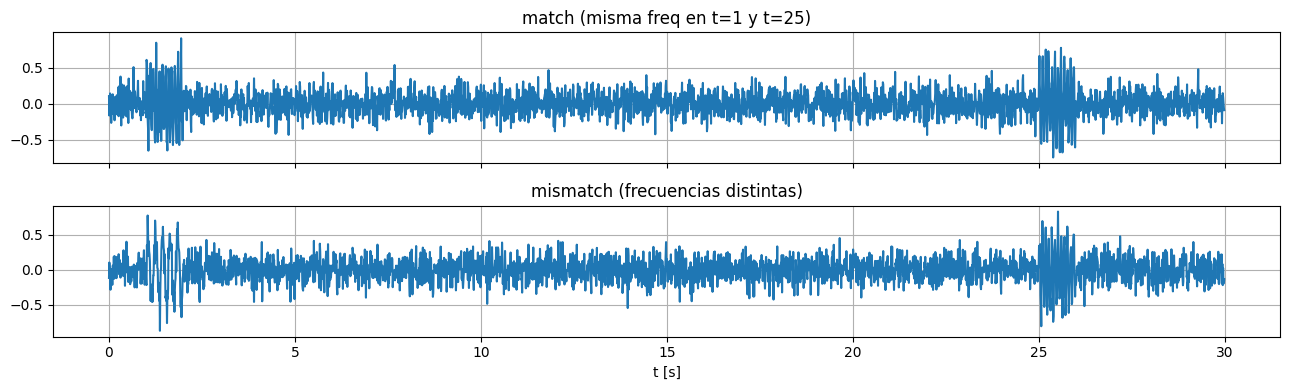

In [ ]:
FS_LC = 100; DUR_LC = 30.0; T_LC = int(DUR_LC * FS_LC)

def make_long_context(label, rng):
    t = np.arange(T_LC) / FS_LC
    sig = 0.15 * rng.standard_normal(T_LC).astype(np.float32)
    f1 = rng.choice([5, 12])
    sig[(t >= 1) & (t < 2)] += 0.5 * np.sin(2*np.pi*f1*t[(t >= 1) & (t < 2)])
    f2 = f1 if label == 0 else (12 if f1 == 5 else 5)
    sig[(t >= 25) & (t < 26)] += 0.5 * np.sin(2*np.pi*f2*t[(t >= 25) & (t < 26)])
    return sig.astype(np.float32)

rng = np.random.default_rng(11); n_per = 400
X_lc = np.stack([make_long_context(c, rng) for c in [0]*n_per + [1]*n_per])
y_lc = np.array([0]*n_per + [1]*n_per, dtype=np.int64)
idx = rng.permutation(len(X_lc)); X_lc, y_lc = X_lc[idx], y_lc[idx]
split = int(0.8*len(X_lc))
X_tr_lc, X_va_lc = X_lc[:split], X_lc[split:]
y_tr_lc, y_va_lc = y_lc[:split], y_lc[split:]

fig, axes = plt.subplots(2, 1, figsize=(13, 4), sharex=True)
axes[0].plot(np.arange(T_LC)/FS_LC, X_lc[y_lc == 0][0]); axes[0].set_title('match (misma freq en t=1 y t=25)')
axes[1].plot(np.arange(T_LC)/FS_LC, X_lc[y_lc == 1][0]); axes[1].set_title('mismatch (frecuencias distintas)')
axes[-1].set_xlabel('t [s]')
plt.tight_layout(); plt.show()

### Demo · una CNN no puede resolver esta tarea

Definimos una CNN razonable (3 conv layers con stride=2) y la entrenamos. Su campo receptivo no llega a abarcar los 30 s — queda en *chance level*.

In [ ]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, 7, stride=2, padding=3), nn.ReLU(),
            nn.Conv1d(16, 32, 5, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(32, 32, 5, stride=2, padding=2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(32, 2))
    def forward(self, x): return self.net(x)

def train_clf(model, X_tr, y_tr, X_va, y_va, epochs=10, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr); crit = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(torch.from_numpy(X_tr).float(), torch.from_numpy(y_tr)),
                        batch_size=32, shuffle=True)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            loss = crit(model(xb.to(device).unsqueeze(1)), yb.to(device))
            opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(torch.from_numpy(X_va).float().to(device).unsqueeze(1)).argmax(1).cpu().numpy()
    return (pred == y_va).mean()

torch.manual_seed(0)
acc_cnn = train_clf(SmallCNN().to(device), X_tr_lc, y_tr_lc, X_va_lc, y_va_lc)
print(f'SmallCNN val_acc = {acc_cnn:.3f}  (chance = 0.50, CNN limitada por campo receptivo)')

SmallCNN val_acc = 0.525  (chance = 0.50, CNN limitada por campo receptivo)


### Ejercicio 3.1 — implementar y entrenar un mini-Transformer 1D (slide 33)

Implementá un Transformer simple que pueda resolver la tarea. La ventaja sobre la CNN es que **self-attention conecta cualquier par de instantes en una sola capa** — sin importar la distancia.

**Arquitectura:**

```
1. Patch embedding
   Conv1D(in=1, out=64, kernel_size=50, stride=50)   # cada patch = 0.5 s
   transpose para quedar [B, N_patches=60, dim=64]

2. Positional embedding (parámetro aprendido)
   nn.Parameter de shape [1, N_patches=60, dim=64], inicializado random pequeño
   Se suma a la salida del patch embedding

3. Bloque de atención (con conexión residual)
   LayerNorm  →  MultiheadAttention(dim=64, num_heads=4, batch_first=True)
   suma residual con la entrada del bloque

4. Bloque feed-forward (con conexión residual)
   LayerNorm  →  Linear(64 → 128)  →  GELU  →  Linear(128 → 64)
   suma residual

5. Clasificador
   promedio sobre patches (mean dim=1)  →  Linear(64 → 2)
```

**Entrenamiento:** 10 epochs, Adam (lr=3e-4), `CrossEntropyLoss`.

Después de entrenar, comparé el `val_acc` con `acc_cnn`. El Transformer debería resolver la tarea (~1.0), mientras que la CNN se queda en chance.

In [ ]:
class MiniTransformer1D(nn.Module):
    """Transformer 1D para clasificación de contexto largo.

    Patch embedding: Conv1d(1, 64, 50, stride=50) → 60 patches de 0.5s
    Positional embedding: aprendido
    1 bloque de atención + 1 bloque feed-forward
    Clasificador: mean pooling → Linear(64, 2)
    """
    EMBED = 64
    N_PATCHES = 60  # 3000 / 50

    def __init__(self, n_classes=2):
        super().__init__()
        # Patch embedding
        self.patch_embed = nn.Conv1d(1, self.EMBED, kernel_size=50, stride=50)  # [B, 64, 60]
        # Positional embedding aprendido
        self.pos_embed = nn.Parameter(0.02 * torch.randn(1, self.N_PATCHES, self.EMBED))

        # Bloque de atención
        self.norm1 = nn.LayerNorm(self.EMBED)
        self.attn  = nn.MultiheadAttention(self.EMBED, num_heads=4, batch_first=True)

        # Bloque feed-forward
        self.norm2 = nn.LayerNorm(self.EMBED)
        self.ff    = nn.Sequential(
            nn.Linear(self.EMBED, 2 * self.EMBED),
            nn.GELU(),
            nn.Linear(2 * self.EMBED, self.EMBED),
        )

        # Clasificador
        self.head = nn.Linear(self.EMBED, n_classes)

    def forward(self, x):
        # x: [B, 1, T] (already unsqueezed by train_clf function)
        # Patch embedding: [B, 64, 60] → [B, 60, 64]
        e = self.patch_embed(x).transpose(1, 2)
        # Suma positional embedding
        e = e + self.pos_embed
        # Bloque de atención con residual
        attn_out, _ = self.attn(self.norm1(e), self.norm1(e), self.norm1(e))
        e = e + attn_out
        # Bloque feed-forward con residual
        e = e + self.ff(self.norm2(e))
        # Clasificador: promedio sobre patches
        return self.head(e.mean(dim=1))

torch.manual_seed(0)
transformer = MiniTransformer1D(n_classes=2).to(device)
n_params_t = sum(p.numel() for p in transformer.parameters())
print(f'MiniTransformer — Parámetros: {n_params_t:,}')
print(f'N_patches: {MiniTransformer1D.N_PATCHES} × {MiniTransformer1D.EMBED}d')
print(f'Cada patch = {50/FS_LC*1000:.0f} ms = {50/FS_LC:.2f} s')

acc_transformer = train_clf(transformer, X_tr_lc, y_tr_lc, X_va_lc, y_va_lc, epochs=10, lr=3e-4)
print(f'\n==> MiniTransformer val_acc = {acc_transformer:.3f}')
print(f'    SmallCNN val_acc         = {acc_cnn:.3f}  (chance = 0.50)')
print(f'    Ganancia del Transformer: {(acc_transformer - acc_cnn)*100:+.1f} pp')

MiniTransformer — Parámetros: 40,706
N_patches: 60 × 64d
Cada patch = 500 ms = 0.50 s

==> MiniTransformer val_acc = 1.000
    SmallCNN val_acc         = 0.525  (chance = 0.50)
    Ganancia del Transformer: +47.5 pp


### Preguntas conceptuales — mini-Transformer (Ej 3.1)

Justificá brevemente cada decisión de la arquitectura. Una o dos oraciones por pregunta.

1. El **patch embedding** es una `Conv1D(kernel=50, stride=50)`. ¿Para qué partir la señal en patches? ¿Qué pasaría si pusiéramos todo el tensor directamente en la atención?
2. ¿Cuántos segundos cubre cada patch (a `fs=100 Hz`) y cuántos patches totales hay en una ventana de 30 s?
3. ¿Para qué hace falta el **positional embedding**? ¿Qué pasaría sin él en una tarea como esta (match/mismatch)?
4. En `MultiheadAttention(dim=64, num_heads=4)`: ¿qué representa cada **cabeza** y por qué se usan varias en paralelo?
5. ¿Por qué hay **conexiones residuales** (`e = e + attn_out`)? ¿Qué problema previenen?
6. ¿Para qué sirve el **bloque feed-forward** después de la atención si ya hicimos atención? ¿Por qué la dimensión interna es `2 × EMBED`?
7. ¿Por qué `LayerNorm` y no `BatchNorm` (como sí usamos en EEGNet)?
8. ¿Por qué hacemos `e.mean(dim=1)` al final antes del clasificador?

1. El patch embedding divide los 3000 samples en 60 patches de 50 muestras (0.5 s) para reducir la longitud de la secuencia que entra a la atención. Con toda la señal sin patchear, la atención costaría O(3000²) — demasiado caro. Con 60 patches, el costo es O(60²), manejable.
2. Cada patch cubre 50/100 = 0.5 s. Con 60 patches totales para 30 s.
3. El positional embedding es esencial porque la atención es una operación de conjuntos — no tiene noción del orden. Sin él, los patches del segundo 1 y del segundo 25 serían indistinguibles en posición para el modelo, y la tarea requiere comparar eventos en posiciones específicas.
4. Cada cabeza atiende con Q, K, V proyectados en d/4 = 16 dimensiones. Distintas cabezas pueden especializarse: una puede comparar el patch 1 con el patch 25, otra puede capturar correlaciones locales, etc. Múltiples cabezas aumentan la expressividad sin aumentar el costo cuadráticamente.
5. Las conexiones residuales previenen el problema del gradiente que desaparece en redes profundas, y permiten que la red aprenda "correcciones" sobre la identidad. También facilitan el aprendizaje inicial: si los pesos empiezan pequeños, el bloque devuelve casi la entrada — un buen punto de partida.
6. El bloque feed-forward aplica una transformación no-lineal posición a posición después de la mezcla de información global. La dimensión interna 2xEMBED = 128 da capacidad para combinar las features de atención de forma compleja. Sin él, la red solo haría combinaciones lineales de los valores atendidos.
7. LayerNorm en vez de BatchNorm porque LayerNorm normaliza sobre la dimensión del embedding (no el batch), lo que es estable para secuencias de largo variable y para batchs pequeños. BatchNorm depende del estadístico del batch — inestable si el largo varía o el batch es chico.
8. e.mean(dim=1) promedia sobre todos los patches para obtener una representación global de la secuencia completa. Alternativamente se usaría un token [CLS], pero el mean pooling es más simple y funciona bien en tareas de clasificación de secuencia completa.

## Cierre — takeaways de la clase

1. **Una señal 1D = lista de números + `fs`.** ECG, EEG y PPG son instancias del mismo concepto.
2. **El filtro deslizante es el throughline.** Pan-Tompkins → Conv1D → self-attention — lo que cambia es **cuántos parámetros**    y **cuánto contexto** ve cada operación.
3. **AI extiende al clásico, no lo reemplaza.** Pan-Tompkins de 1985 sigue siendo baseline en producción.
4. **Dimensionalidad escala el problema.** ECG (1D) → PPG (1D + movimiento) → EEG (2D = canales × tiempo). El framework es el mismo;    la arquitectura se adapta.
5. **Las CNNs tienen campo receptivo finito.** Cuando la tarea requiere contexto largo, hay que ir a Transformers.